In [1]:
using DataFrames, CSV, XLSX, Statistics

In [2]:
using Turing
using DifferentialEquations
using StatsPlots
using LinearAlgebra
import NaNMath

In [3]:
data = CSV.File("resistant.csv") |> DataFrame
experiment_times = [72.0, 120.0]
experiment_re = [
    mean([data[1, :rep1], data[1, :rep2], data[1, :rep3]]),
    mean([data[2, :rep1], data[2, :rep2], data[2, :rep3]])
]

println("time", experiment_times)
println("the percentage of resisant cells：", experiment_re)

time[72.0, 120.0]
the percentage of resisant cells：[0.11333333333333333, 0.9715315316666668]


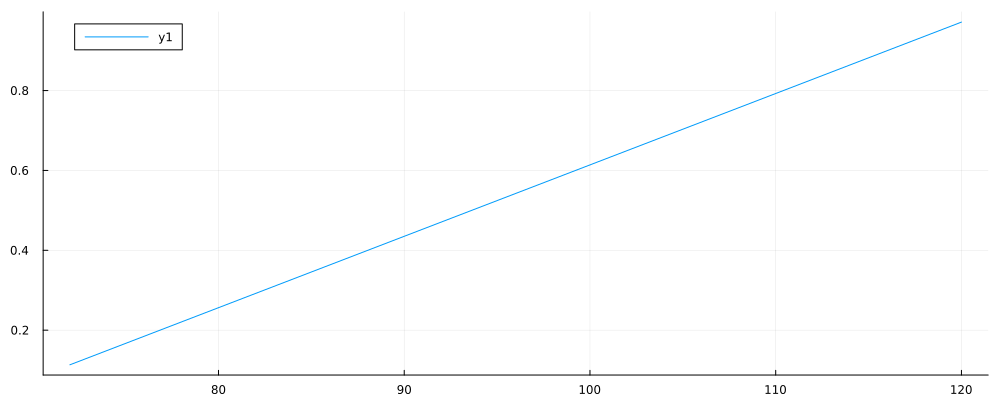

In [4]:
re = plot(experiment_times,experiment_re)

plot(re, size = (1000,400))

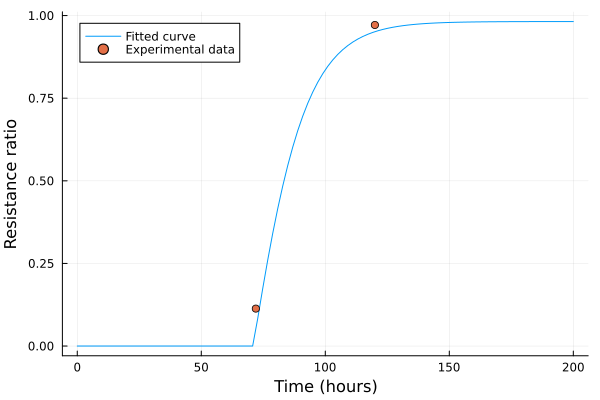

In [5]:
# Define the function of the proportion of resistant cells changing over time
function resistance_ratio(t)
    # Using Sigmoid
    # r(t) = a + (b-a)/(1 + exp(-k*(t-t0)))
   
    if t < 72
        return 0.0  # Resistance only happens after 72 hours of the infection
    else
        a = -0.9    # initail ratio
        b = 0.982   # final ratio(0.972)
        k = 0.08    # growth rate(0.15)
        t0 = 55     # turning point(85)
        n = 3       # shape parameter(2)
        
        ratio = a + (b-a)/(1 + exp(-k*(t-t0)))^n
        return min(ratio, b)  
    end
end

export resistance_ratio

# fitting curve
t_range = range(0, 200, length=100)
fitted_curve = [resistance_ratio(t) for t in t_range]
p = plot(t_range, fitted_curve, label="Fitted curve", xlabel="Time (hours)", ylabel="Resistance ratio")
scatter!(experiment_times, experiment_re, label="Experimental data")


In [6]:
using Random
Random.seed!(10);

In [7]:
using DataFrames, XLSX

In [8]:
med4 = DataFrame(XLSX.readtable("PSSP7_ZT145.xlsx", "Host"))
rename!(med4, [:time, :rep1, :rep2])
t_obs_pro = med4.time
obsdata_pro = (med4.rep1 .+ med4.rep2) ./ 2

virus = DataFrame(XLSX.readtable("PSSP7_ZT145.xlsx", "Virus"))
rename!(virus, [:time, :rep1, :rep2])
t_obs_virus = virus.time
obsdata_virus = (virus.rep1 .+ virus.rep2) ./ 2
nothing

In [9]:
function pro_virus_basic(du, u, p, t)
    # state variables
    Su = u[1] # susceptible host cells
    Ex = u[2] # exposed host cells
    In = u[3] # infected host cells and the capsid-protected progeny phages appear
    Vi = u[4] # virus
    Re = u[5] # resistant host cells(cannot transfer from Ex to In)
    

    # parameters
    μmax = p[1] # maximum growth rate at Lopt (h⁻¹)
    Lopt = p[2] # optimal light (μmol s⁻¹ m⁻²)
    α    = p[3] # initial slope of the light response curve (h⁻¹)
    KL   = p[4] # minimum amount of light necessary for cell division (μmol s⁻¹ m⁻²)
    ω    = p[5] # hose basal mortality (h⁻¹)
    K    = p[6] # host carrying capacity (cells ml⁻¹)
    ϕ    = p[7] # adsorption rate (ml h⁻¹)
    β    = p[8] # burst size (unitless)
    λ   = p[9] # average eclise period (h)(the time between phage attachemnt and the appearence of capsid-protected phages)
    μ_re = p[10] #the cost of resistance (unitless)
    δ    = p[11] # viral decay rate (h⁻¹)
    
    
    # light -- hourly data
    n_light = 14; n_dark = 10
    L = 35 # μmol s⁻¹ m⁻²
    # t in hours
    τ = rem(t, 24) # time of day
    
    # light dependent growth rate
    μopt = μmax * L / (L + μmax / α * (L / Lopt - 1.0)^2)
    Lt = L * τ * (1.0 - isless(n_light, τ)) + L * (n_light - (τ - n_dark)) * n_light / n_dark * isless(n_light, τ)
    μ = μopt * Lt^4 / (Lt^4 + KL^4)
    # Calculate resistance ratio based on time
    r = resistance_ratio(t)

    total_cells = Su + Ex + In + Re
    carrying_capacity_factor = max(1.0 - total_cells/K, 0.0)
    

    du[1] = μ * Su * carrying_capacity_factor - ω * Su - ϕ * Su * Vi           # dSu/dt
    du[2] = ϕ * Su * Vi - ω * Ex - Ex / λ                                     # dEx/dt
    du[3] = (1-r) * Ex / λ - ω * In - In / λ                                     # dIn/dt 
    du[4] = β * In / λ -  ϕ * Su * Vi - δ * Vi                                 # dVi/dt
    du[5] = r * Ex / λ + μ * Re * carrying_capacity_factor * μ_re - 14.0 * ω * Re # dRe/dt
    #                                                                ========
    # here I'm using a different ω for resistant cells

    #=
   for i in 1:5
      du[i] = clamp(du[i], -1e3*u[i], 1e3*u[i])
      u[i] = clamp(u[i], 0.0, i == 4 ? 1e12 : K)  # set the upper limit of virus to 1e12, and the other to K
   end
    =#

   return nothing
end

#export resistance_ratio, pro_virus_basic 

pro_virus_basic (generic function with 1 method)

In [ ]:
using Random
Random.seed!(42)  # 设置随机种子，保证可重复性

# ============================================================
# 首先测试原始参数是否能成功求解
# ============================================================
println("=" ^ 60)
println("测试原始参数...")
u0_test = [obsdata_pro[1], obsdata_pro[1]*1e-6, obsdata_pro[1]*1e-6, obsdata_virus[1], obsdata_pro[1]*1e-12]
# 原始参数: [μmax, Lopt, α, KL, ω, K, ϕ, β, λ, μ_re, δ]
p_original = [0.025, 45.78, 6.1e-4, 255.0, 0.0015, 2.8e9, 0.2e-8, 200.0, 65.0, 0.5, 6e-4]
tspan_test = (14.0, 136.0)
prob_test = ODEProblem(pro_virus_basic, u0_test, tspan_test, p_original)
sol_test = solve(prob_test, Tsit5(); saveat=1.0, abstol=1e-8, reltol=1e-8)
println("原始参数求解状态: $(sol_test.retcode)")
println("=" ^ 60)

# ============================================================
# 定义参数范围 (基于原始参数的 ±200% 范围，扩大搜索空间)
# ============================================================
# 原始参数: [0.025, 45.78, 6.1e-4, 255.0, 0.0015, 2.8e9, 0.2e-8, 200.0, 65, 0.5, 6e-4]
param_ranges = Dict(
    :μmax => (0.00833, 0.075),      # 最大生长率 (h⁻¹) - 原值 0.025 (±200%)
    :Lopt => (15.26, 137.34),       # 最适光强 - 原值 45.78 (±200%)
    :α    => (2.03e-4, 1.83e-3),    # 光响应曲线初始斜率 - 原值 6.1e-4 (±200%)
    :KL   => (85.0, 765.0),         # 最低光强 - 原值 255.0 (±200%)
    :ω    => (0.0005, 0.0045),      # 宿主基础死亡率 - 原值 0.0015 (±200%)
    :K    => (9.33e8, 8.4e9),       # 环境容纳量 - 原值 2.8e9 (±200%)
    :ϕ    => (6.67e-10, 6e-9),      # 吸附速率 - 原值 2e-9 (0.2e-8) (±200%)
    :β    => (66.67, 600.0),        # 裂解量 - 原值 200 (±200%)
    :λ    => (21.67, 195.0),        # 潜伏期 (h) - 原值 65 (±200%)
    :μ_re => (0.167, 1.5),          # 抗性代价因子 - 原值 0.5 (±200%)
    :δ    => (2e-4, 1.8e-3)         # 病毒衰减率 - 原值 6e-4 (±200%)
)

# 参数名称顺序（与模型中 p 向量的顺序一致）
param_names = [:μmax, :Lopt, :α, :KL, :ω, :K, :ϕ, :β, :λ, :μ_re, :δ]

# ============================================================
# 生成随机参数组合
# ============================================================
n_samples = 10000  # 生成 10000 组随机参数

# 从均匀分布中随机采样
function sample_parameters(ranges, names, n)
    params = []
    for i in 1:n
        p = [rand() * (ranges[name][2] - ranges[name][1]) + ranges[name][1] for name in names]
        push!(params, p)
    end
    return params
end

# 生成参数集合
param_sets = sample_parameters(param_ranges, param_names, n_samples)

println("生成了 $(n_samples) 组随机参数组合")
println("\n参数范围：")
for name in param_names
    println("  $(name): $(param_ranges[name])")
end

# 显示前 5 组参数示例
println("\n前 5 组参数示例：")
for i in 1:min(5, n_samples)
    println("  参数组 $i: ", round.(param_sets[i], sigdigits=3))
end

# ============================================================
# 初始条件和时间范围
# ============================================================
# 5个状态变量: [Su, Ex, In, Vi, Re]
u0 = [obsdata_pro[1], obsdata_pro[1]*1e-6, obsdata_pro[1]*1e-6, obsdata_virus[1], obsdata_pro[1]*1e-12]
tspan = (14.0, 136.0)

# ============================================================
# 定义拟合优度评估函数
# ============================================================
"""
计算模型预测与观测数据的拟合优度
返回: (RMSE_host, RMSE_virus, R²_host, R²_virus, total_score)
注意: 这个模型的宿主总数 = Su + Ex + In + Re
"""
function evaluate_fit(sol, t_obs_host, obs_host, t_obs_virus, obs_virus)
    # 在观测时间点插值获取模型预测值
    # 宿主：总细胞数 = Su + Ex + In + Re (包含抗性细胞)
    pred_host = [sol(t)[1] + sol(t)[2] + sol(t)[3] + sol(t)[5] for t in t_obs_host]
    # 病毒
    pred_virus = [sol(t)[4] for t in t_obs_virus]
    
    # 计算 RMSE (均方根误差)
    rmse_host = sqrt(mean((pred_host .- obs_host).^2))
    rmse_virus_log = sqrt(mean((log10.(max.(pred_virus, 1.0)) .- log10.(max.(obs_virus, 1.0))).^2))
    
    # 计算 R² (决定系数)
    ss_res_host = sum((pred_host .- obs_host).^2)
    ss_tot_host = sum((obs_host .- mean(obs_host)).^2)
    r2_host = 1 - ss_res_host / ss_tot_host
    
    ss_res_virus = sum((log10.(max.(pred_virus, 1.0)) .- log10.(max.(obs_virus, 1.0))).^2)
    ss_tot_virus = sum((log10.(max.(obs_virus, 1.0)) .- mean(log10.(max.(obs_virus, 1.0)))).^2)
    r2_virus = 1 - ss_res_virus / ss_tot_virus
    
    # 归一化 RMSE (相对于观测数据的标准差)
    nrmse_host = rmse_host / std(obs_host)
    nrmse_virus = rmse_virus_log / std(log10.(max.(obs_virus, 1.0)))
    
    # 综合评分 (越小越好)
    total_score = 0.5 * nrmse_host + 0.5 * nrmse_virus
    
    return (rmse_host=rmse_host, rmse_virus=rmse_virus_log, 
            r2_host=r2_host, r2_virus=r2_virus,
            nrmse_host=nrmse_host, nrmse_virus=nrmse_virus,
            total_score=total_score)
end

# ============================================================
# 设置筛选标准
# ============================================================
R2_THRESHOLD_HOST = 0.5      # 宿主 R² 至少 0.5
R2_THRESHOLD_VIRUS = 0.5     # 病毒 R² 至少 0.5
NRMSE_THRESHOLD = 1.0        # NRMSE < 1 表示误差小于数据标准差
TOP_PERCENT = 10             # 保留最好的 10%

println("\n筛选标准：")
println("  R² 阈值 (宿主): ≥ $(R2_THRESHOLD_HOST)")
println("  R² 阈值 (病毒): ≥ $(R2_THRESHOLD_VIRUS)")
println("  NRMSE 阈值: ≤ $(NRMSE_THRESHOLD)")
println("  保留最好的: $(TOP_PERCENT)%")

# ============================================================
# 对所有参数组合求解 ODE 并评估
# ============================================================
all_solutions = []
successful_params = []
fit_scores = []
failed_reasons = Dict{Symbol, Int}()

println("\n开始求解和评估...")

for (i, p) in enumerate(param_sets)
    prob = ODEProblem(pro_virus_basic, u0, tspan, p)
    try
        sol = solve(prob, Tsit5(); 
                    saveat=0.1,
                    abstol=1e-6, 
                    reltol=1e-6,
                    maxiters=1e7)
        
        if sol.retcode == ReturnCode.Success
            # 评估拟合优度
            fit_result = evaluate_fit(sol, t_obs_pro, obsdata_pro, t_obs_virus, obsdata_virus)
            
            push!(all_solutions, sol)
            push!(successful_params, p)
            push!(fit_scores, fit_result)
        else
            reason = Symbol(sol.retcode)
            failed_reasons[reason] = get(failed_reasons, reason, 0) + 1
        end
    catch e
        failed_reasons[:Exception] = get(failed_reasons, :Exception, 0) + 1
    end
    
    # 进度显示
    if i % 1000 == 0
        println("  已处理: $i / $n_samples")
    end
end

println("\n成功求解: $(length(all_solutions)) / $(n_samples) 组参数")

# ============================================================
# 根据标准筛选参数
# ============================================================
good_by_r2 = findall(s -> s.r2_host >= R2_THRESHOLD_HOST && s.r2_virus >= R2_THRESHOLD_VIRUS, fit_scores)
good_by_nrmse = findall(s -> s.nrmse_host <= NRMSE_THRESHOLD && s.nrmse_virus <= NRMSE_THRESHOLD, fit_scores)
n_top = max(1, Int(ceil(length(fit_scores) * TOP_PERCENT / 100)))
sorted_indices = sortperm([s.total_score for s in fit_scores])
good_by_top = sorted_indices[1:n_top]
good_indices = intersect(good_by_r2, good_by_nrmse)

println("\n筛选结果：")
println("  通过 R² 阈值: $(length(good_by_r2)) 组")
println("  通过 NRMSE 阈值: $(length(good_by_nrmse)) 组")
println("  最好的 $(TOP_PERCENT)%: $(length(good_by_top)) 组")
println("  综合通过: $(length(good_indices)) 组")

# ============================================================
# 显示最佳参数组合
# ============================================================
if length(fit_scores) > 0
    best_idx = sorted_indices[1]
    best_params = successful_params[best_idx]
    best_score = fit_scores[best_idx]
    
    println("\n" * "=" ^ 60)
    println("最佳参数组合：")
    println("=" ^ 60)
    for (i, name) in enumerate(param_names)
        println("  $(name) = $(round(best_params[i], sigdigits=4))")
    end
    println("\n拟合优度：")
    println("  R² (宿主): $(round(best_score.r2_host, digits=4))")
    println("  R² (病毒): $(round(best_score.r2_virus, digits=4))")
    println("  NRMSE (宿主): $(round(best_score.nrmse_host, digits=4))")
    println("  NRMSE (病毒): $(round(best_score.nrmse_virus, digits=4))")
    println("  综合评分: $(round(best_score.total_score, digits=4))")
end

# ============================================================
# 绑图：显示筛选后的结果
# ============================================================
# 使用所有通过筛选标准的参数组合绑图
plot_indices = good_indices

# 图1: 宿主细胞分解
p1 = plot(
    xlabel="Time (h)",
    ylabel="Cell count (cells/mL)",
    legend=:outertopright,
    left_margin=8Plots.mm,
    bottom_margin=6Plots.mm,
    title="Host Cells - All Passed ($(length(plot_indices)) sets)"
)

# 图2: 病毒
p2 = plot(
    xlabel="Time (h)",
    ylabel="Virus count (copies/mL)",
    yscale=:log10,
    legend=:outertopright,
    left_margin=8Plots.mm,
    bottom_margin=6Plots.mm,
    title="Virus - All Passed ($(length(plot_indices)) sets)"
)

# 图3: 总宿主（含抗性细胞）
p3 = plot(
    xlabel="Time (h)",
    ylabel="Cell count (cells/mL)",
    legend=:outertopright,
    left_margin=8Plots.mm,
    bottom_margin=6Plots.mm,
    title="Total Host (incl. Resistant)"
)

# 图4: 抗性细胞
p4 = plot(
    xlabel="Time (h)",
    ylabel="Cell count (cells/mL)",
    legend=:outertopright,
    left_margin=8Plots.mm,
    bottom_margin=6Plots.mm,
    title="Resistant Cells"
)

# 绑制筛选后的曲线
for idx in plot_indices
    sol = all_solutions[idx]
    sol_array = Array(sol)'
    # 总宿主（不含抗性）
    total_host_no_re = sol_array[:,1] .+ sol_array[:,2] .+ sol_array[:,3]
    # 总宿主（含抗性）
    total_host = total_host_no_re .+ sol_array[:,5]
    
    plot!(p1, sol.t, total_host_no_re, alpha=0.3, color=:blue, label="")
    plot!(p2, sol.t, sol_array[:,4], alpha=0.3, color=:red, label="")
    plot!(p3, sol.t, total_host, alpha=0.3, color=:green, label="")
    plot!(p4, sol.t, sol_array[:,5], alpha=0.3, color=:purple, label="")
end

# 绑制最佳拟合曲线（加粗）
if length(fit_scores) > 0
    best_sol = all_solutions[best_idx]
    best_array = Array(best_sol)'
    best_host_no_re = best_array[:,1] .+ best_array[:,2] .+ best_array[:,3]
    best_host = best_host_no_re .+ best_array[:,5]
    
    plot!(p1, best_sol.t, best_host_no_re, linewidth=3, color=:darkblue, label="Best fit")
    plot!(p2, best_sol.t, best_array[:,4], linewidth=3, color=:darkred, label="Best fit")
    plot!(p3, best_sol.t, best_host, linewidth=3, color=:darkgreen, label="Best fit")
    plot!(p4, best_sol.t, best_array[:,5], linewidth=3, color=:purple, label="Best fit")
end

# 添加观测数据点
scatter!(p1, t_obs_pro, obsdata_pro, label="Host data", color=:black, markersize=6)
scatter!(p2, t_obs_virus, obsdata_virus, label="Virus data", color=:black, markersize=6)
scatter!(p3, t_obs_pro, obsdata_pro, label="Host data", color=:black, markersize=6)

# 图5: 抗性比例
p5 = plot(0:136, resistance_ratio.(0:136), label="Resistance ratio function", 
          xlabel="Time (h)", ylabel="Resistance ratio", linewidth=2)
scatter!(p5, experiment_times, experiment_re, label="Experimental data", markersize=8)

# 组合图
plot(p1, p2, p3, p4, p5, size=(1200, 800), layout=(3, 2))

测试原始参数...
原始参数求解状态: Success
生成了 10000 组随机参数组合

参数范围：
  μmax: (0.00833, 0.075)
  Lopt: (15.26, 137.34)
  α: (0.000203, 0.00183)
  KL: (85.0, 765.0)
  ω: (0.0005, 0.0045)
  K: (9.33e8, 8.4e9)
  ϕ: (6.67e-10, 6.0e-9)
  β: (66.67, 600.0)
  λ: (21.67, 195.0)
  μ_re: (0.167, 1.5)
  δ: (0.0002, 0.0018)

前 5 组参数示例：
  参数组 1: [0.0503, 70.2, 0.00098, 563.0, 0.00319, 2.17e9, 3.94e-9, 423.0, 101.0, 0.566, 0.00126]
  参数组 2: [0.051, 57.1, 0.000639, 436.0, 0.00086, 2.97e9, 1.69e-9, 293.0, 106.0, 0.274, 0.00102]
  参数组 3: [0.0214, 88.6, 0.00085, 300.0, 0.00224, 7.34e9, 2.37e-9, 367.0, 77.5, 0.378, 0.00136]
  参数组 4: [0.0332, 18.9, 0.000332, 536.0, 0.00247, 6.26e9, 1.55e-9, 348.0, 102.0, 1.31, 0.000478]
  参数组 5: [0.0281, 137.0, 0.000782, 582.0, 0.00353, 5.56e9, 2.16e-9, 237.0, 117.0, 0.993, 0.000752]

筛选标准：
  R² 阈值 (宿主): ≥ 0.5
  R² 阈值 (病毒): ≥ 0.5
  NRMSE 阈值: ≤ 1.0
  保留最好的: 10%

开始求解和评估...
  已处理: 1000 / 10000
  已处理: 2000 / 10000
  已处理: 3000 / 10000
  已处理: 4000 / 10000
  已处理: 5000 / 10000
  已处理: 6000 / 1000

In [ ]:
# ============================================================
# 保存结果到文件 - 保留所有通过筛选标准的参数组合
# ============================================================
using Dates

ts = Dates.format(now(), "yyyymmdd_HHMMSS")

# ============================================================
# 计算通过比例
# ============================================================
n_total = n_samples
n_solved = length(all_solutions)
n_pass_r2 = length(good_by_r2)
n_pass_nrmse = length(good_by_nrmse)
n_pass_all = length(good_indices)

ratio_solved = n_solved / n_total * 100
ratio_pass_r2 = n_pass_r2 / n_solved * 100
ratio_pass_nrmse = n_pass_nrmse / n_solved * 100
ratio_pass_all = n_pass_all / n_solved * 100
ratio_pass_all_total = n_pass_all / n_total * 100

println("=" ^ 70)
println("📊 筛选结果统计")
println("=" ^ 70)
println("\n采样与求解：")
println("  总采样数:        $(n_total)")
println("  成功求解:        $(n_solved) ($(round(ratio_solved, digits=2))%)")

println("\n筛选通过统计：")
println("  通过 R² 阈值:    $(n_pass_r2) / $(n_solved) = $(round(ratio_pass_r2, digits=2))%")
println("  通过 NRMSE 阈值: $(n_pass_nrmse) / $(n_solved) = $(round(ratio_pass_nrmse, digits=2))%")
println("  综合通过:        $(n_pass_all) / $(n_solved) = $(round(ratio_pass_all, digits=2))%")
println("  总通过率:        $(n_pass_all) / $(n_total) = $(round(ratio_pass_all_total, digits=2))%")

# ============================================================
# 1. 保存最佳参数到 CSV
# ============================================================
best_params_df = DataFrame(
    Parameter = String.(param_names),
    Value = best_params,
    Description = [
        "最大生长率 (h⁻¹)",
        "最适光强 (μmol s⁻¹ m⁻²)",
        "光响应曲线初始斜率",
        "最低光强 (μmol s⁻¹ m⁻²)",
        "宿主基础死亡率 (h⁻¹)",
        "环境容纳量 (cells/mL)",
        "吸附速率 (mL h⁻¹)",
        "裂解量",
        "潜伏期 (h)",
        "抗性代价因子",
        "病毒衰减率 (h⁻¹)"
    ]
)
CSV.write("resistance_best_params_$(ts).csv", best_params_df)

# ============================================================
# 2. 保存所有通过筛选标准的参数组合
# ============================================================
passed_params_df = DataFrame()
for (i, name) in enumerate(param_names)
    passed_params_df[!, name] = [successful_params[idx][i] for idx in good_indices]
end
passed_params_df[!, :R2_host] = [fit_scores[idx].r2_host for idx in good_indices]
passed_params_df[!, :R2_virus] = [fit_scores[idx].r2_virus for idx in good_indices]
passed_params_df[!, :NRMSE_host] = [fit_scores[idx].nrmse_host for idx in good_indices]
passed_params_df[!, :NRMSE_virus] = [fit_scores[idx].nrmse_virus for idx in good_indices]
passed_params_df[!, :total_score] = [fit_scores[idx].total_score for idx in good_indices]

sort!(passed_params_df, :total_score)
CSV.write("resistance_passed_params_all_$(ts).csv", passed_params_df)

# ============================================================
# 3. 计算通过参数的统计摘要
# ============================================================
println("\n" * "=" ^ 70)
println("📈 通过筛选参数的统计摘要")
println("=" ^ 70)
println("\n参数统计 ($(n_pass_all) 组通过筛选)：")
println("-" ^ 70)
println(rpad("参数", 10), rpad("均值", 15), rpad("标准差", 15), rpad("最小值", 15), "最大值")
println("-" ^ 70)
for name in param_names
    vals = passed_params_df[!, name]
    m = mean(vals)
    s = std(vals)
    mi = minimum(vals)
    ma = maximum(vals)
    println(rpad(string(name), 10), 
            rpad(string(round(m, sigdigits=4)), 15),
            rpad(string(round(s, sigdigits=4)), 15),
            rpad(string(round(mi, sigdigits=4)), 15),
            string(round(ma, sigdigits=4)))
end

# ============================================================
# 4. 保存图片
# ============================================================
savefig(p1, "resistance_figure_host_$(ts).pdf")
savefig(p2, "resistance_figure_virus_$(ts).pdf")
savefig(p3, "resistance_figure_total_host_$(ts).pdf")
savefig(p4, "resistance_figure_resistant_cells_$(ts).pdf")
savefig(p5, "resistance_figure_ratio_$(ts).pdf")

# ============================================================
# 5. 显示结果摘要
# ============================================================
println("\n" * "=" ^ 70)
println("📊 最佳参数组合")
println("=" ^ 70)
for (i, name) in enumerate(param_names)
    println("  $(rpad(string(name), 8)) = $(best_params[i])")
end
println("\n拟合优度：")
println("  R² (宿主):    $(round(best_score.r2_host, digits=4)) (解释了 $(round(best_score.r2_host*100, digits=1))% 的数据变异)")
println("  R² (病毒):    $(round(best_score.r2_virus, digits=4)) (解释了 $(round(best_score.r2_virus*100, digits=1))% 的数据变异)")
println("  NRMSE (宿主): $(round(best_score.nrmse_host, digits=4)) (误差为数据标准差的 $(round(best_score.nrmse_host*100, digits=1))%)")
println("  NRMSE (病毒): $(round(best_score.nrmse_virus, digits=4)) (误差为数据标准差的 $(round(best_score.nrmse_virus*100, digits=1))%)")

println("\n" * "=" ^ 70)
println("📁 保存的文件")
println("=" ^ 70)
println("  resistance_best_params_$(ts).csv           - 最佳参数 (1 组)")
println("  resistance_passed_params_all_$(ts).csv     - 所有通过筛选的参数 ($(n_pass_all) 组)")
println("  resistance_figure_host_$(ts).pdf           - 宿主拟合图")
println("  resistance_figure_virus_$(ts).pdf          - 病毒拟合图")
println("  resistance_figure_total_host_$(ts).pdf     - 总宿主（含抗性）")
println("  resistance_figure_resistant_cells_$(ts).pdf - 抗性细胞")
println("  resistance_figure_ratio_$(ts).pdf          - 抗性比例")
println("\n保存目录: $(pwd())")